In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Example: adjust source path to your real path
!cp -r "/content/drive/MyDrive/Ear/Otoscopic_Data" "/content/ear"


In [3]:
DATA_ROOT = '/content/ear'

In [4]:
# 2. Create train/val/test splits (70/20/10 default) and copy files
import os, shutil, random
from pathlib import Path

def create_splits(src_root, out_root, train_pct=0.7, val_pct=0.2, test_pct=0.1, seed=42):
    random.seed(seed)
    src_root = Path(src_root)
    out_root = Path(out_root)
    if out_root.exists():
        print("Warning: output folder exists. Files may be overwritten.")
    for split in ['train','val','test']:
        (out_root/split).mkdir(parents=True, exist_ok=True)
    classes = [d for d in src_root.iterdir() if d.is_dir()]
    for cls in classes:
        files = [p for p in cls.iterdir() if p.is_file()]
        random.shuffle(files)
        n = len(files)
        n_train = int(n * train_pct)
        n_val = int(n * val_pct)
        train_files = files[:n_train]
        val_files = files[n_train:n_train+n_val]
        test_files = files[n_train+n_val:]
        for split, split_files in [('train',train_files), ('val',val_files), ('test',test_files)]:
            dest = out_root/split/cls.name
            dest.mkdir(parents=True, exist_ok=True)
            for f in split_files:
                shutil.copy(f, dest/f.name)

OUT_ROOT = '/content/otitis_dataset'  # working dataset with splits
create_splits(DATA_ROOT, OUT_ROOT, train_pct=0.7, val_pct=0.2, test_pct=0.1)
print("Done splitting. Check:", OUT_ROOT)


Done splitting. Check: /content/otitis_dataset


In [6]:
from pathlib import Path
import os

# Update these paths as needed
RAW_ROOT = Path('/content/drive/MyDrive/Otoscopic_Data')   # your original raw dataset (class folders here)
SPLIT_ROOT = Path('/content/otitis_dataset')                  # your split dataset used for preprocessing (train/val/test)
PREP_ROOT = Path('/content/otitis_dataset_preprocessed_fixed')# your preprocessed output

missing_classes = ['Myringosclerosis', 'Normal']

def list_folder(path, max_show=50):
    p = Path(path)
    if not p.exists():
        print("MISSING PATH:", p)
        return
    files = sorted([f.name for f in p.iterdir() if f.is_file()])
    print(f"\n{p}  (total files: {len(files)})")
    for fname in files[:max_show]:
        print(" -", fname)
    if len(files) > max_show:
        print(" ...", len(files)-max_show, "more")

# Check raw root
print("=== Raw dataset (per-class) ===")
for cls in missing_classes:
    list_folder(RAW_ROOT/cls)

# Check split root (train only) — to ensure split contains files for these classes
print("\n=== Split dataset (train) ===")
for cls in missing_classes:
    list_folder(SPLIT_ROOT/'train'/cls)

# Check preprocessed output (train) — confirm empty
print("\n=== Preprocessed output (train) ===")
for cls in missing_classes:
    list_folder(PREP_ROOT/'train'/cls)


=== Raw dataset (per-class) ===
MISSING PATH: /content/drive/MyDrive/Otoscopic_Data/Myringosclerosis
MISSING PATH: /content/drive/MyDrive/Otoscopic_Data/Normal

=== Split dataset (train) ===

/content/otitis_dataset/train/Myringosclerosis  (total files: 420)
 - mys (1).jpg
 - mys (100).jpg
 - mys (101).jpg
 - mys (102).jpg
 - mys (103).jpg
 - mys (104).jpg
 - mys (106).jpg
 - mys (107).jpg
 - mys (108).jpg
 - mys (109).jpg
 - mys (11).jpg
 - mys (112).jpg
 - mys (113).jpg
 - mys (114).jpg
 - mys (115).jpg
 - mys (119).jpg
 - mys (12).jpg
 - mys (120).jpg
 - mys (121).jpg
 - mys (122).jpg
 - mys (125).jpg
 - mys (128).jpg
 - mys (129).jpg
 - mys (130).jpg
 - mys (133).jpg
 - mys (135).jpg
 - mys (136).jpg
 - mys (137).jpg
 - mys (138).jpg
 - mys (140).jpg
 - mys (141).jpg
 - mys (143).jpg
 - mys (144).jpg
 - mys (146).jpg
 - mys (147).jpg
 - mys (15).jpg
 - mys (150).jpg
 - mys (151).jpg
 - mys (152).jpg
 - mys (154).jpg
 - mys (155).jpg
 - mys (156).jpg
 - mys (157).jpg
 - mys (159).jp

In [7]:
import random, shutil
from pathlib import Path

SRC_ROOT = Path('/content/ear')  # correct raw source
OUT_ROOT = Path('/content/otitis_dataset')                # where train/val/test will be created
TRAIN_PCT, VAL_PCT, TEST_PCT = 0.7, 0.2, 0.1
SEED = 42

# remove old OUT_ROOT if it exists (optional) — uncomment to reset
# if OUT_ROOT.exists():
#     shutil.rmtree(OUT_ROOT)

OUT_ROOT.mkdir(parents=True, exist_ok=True)
for split in ['train','val','test']:
    (OUT_ROOT/split).mkdir(parents=True, exist_ok=True)

random.seed(SEED)

classes = [d for d in SRC_ROOT.iterdir() if d.is_dir()]
print("Classes to split:", [c.name for c in classes])

for cls in classes:
    files = [p for p in cls.iterdir() if p.is_file()]
    if len(files) == 0:
        print(f"Skipping empty class folder (no files): {cls.name}")
        continue
    random.shuffle(files)
    n = len(files)
    n_train = int(n * TRAIN_PCT)
    n_val = int(n * VAL_PCT)
    train_files = files[:n_train]
    val_files = files[n_train:n_train+n_val]
    test_files = files[n_train+n_val:]
    for split, split_files in [('train',train_files), ('val',val_files), ('test',test_files)]:
        dest = OUT_ROOT / split / cls.name
        dest.mkdir(parents=True, exist_ok=True)
        for f in split_files:
            shutil.copy(f, dest / f.name)

print("Splitting complete. Check:", OUT_ROOT)
# quick counts
for split in ['train','val','test']:
    print(split, {d.name: len(list(d.glob('*'))) for d in (OUT_ROOT/split).iterdir() if d.is_dir()})


Classes to split: ['Cerumen Impaction', 'Normal', 'Chronic Otitis Media', 'Acute Otitis Media', 'Myringosclerosis']
Splitting complete. Check: /content/otitis_dataset
train {'Cerumen Impaction': 420, 'Normal': 420, 'Chronic Otitis Media': 420, 'Acute Otitis Media': 420, 'Myringosclerosis': 420}
val {'Cerumen Impaction': 120, 'Normal': 120, 'Chronic Otitis Media': 120, 'Acute Otitis Media': 120, 'Myringosclerosis': 120}
test {'Cerumen Impaction': 60, 'Normal': 60, 'Chronic Otitis Media': 60, 'Acute Otitis Media': 60, 'Myringosclerosis': 60}


In [8]:
# Robust preprocessing: PIL-first, CLAHE, denoise, resize, save JPEG
from PIL import Image, ImageOps, UnidentifiedImageError
import numpy as np, cv2, traceback
from pathlib import Path
from tqdm import tqdm

IN_SPLIT_ROOT = Path('/content/otitis_dataset')                    # input splits created above
OUT_PREP_ROOT = Path('/content/otitis_dataset_preprocessed_retry') # output preprocessed
OUT_PREP_ROOT.mkdir(parents=True, exist_ok=True)
IMG_SIZE = (224,224)

success_log = OUT_PREP_ROOT/'success_log.txt'
fail_log = OUT_PREP_ROOT/'fail_log.txt'
success_log.write_text('')
fail_log.write_text('')

def load_pil_then_cv(path):
    try:
        with Image.open(path) as im:
            im = ImageOps.exif_transpose(im)
            im = im.convert('RGB')
            return np.array(im)
    except Exception as e:
        img = cv2.imread(str(path))
        if img is None:
            raise RuntimeError(f"PIL failed ({repr(e)}), cv2 returned None")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img

for split in ['train','val','test']:
    for clsdir in sorted((IN_SPLIT_ROOT/split).glob('*')):
        if not clsdir.is_dir(): continue
        out_cls = OUT_PREP_ROOT/split/clsdir.name
        out_cls.mkdir(parents=True, exist_ok=True)
        print(f"\nProcessing {split}/{clsdir.name}  (files: {len(list(clsdir.glob('*')))})")
        for p in tqdm(sorted(clsdir.glob('*')), leave=False):
            try:
                arr = load_pil_then_cv(p)
                # convert RGB->BGR for cv2 processing
                bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
                lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
                l,a,b = cv2.split(lab)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                cl = clahe.apply(l)
                lab = cv2.merge((cl,a,b))
                img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
                den = cv2.fastNlMeansDenoisingColored(img_clahe, None, 10,10,7,21)
                resized = cv2.resize(den, IMG_SIZE, interpolation=cv2.INTER_AREA)
                outname = p.stem + "_" + str(abs(hash(str(p))))[:8] + ".jpg"
                cv2.imwrite(str(out_cls/outname), resized, [int(cv2.IMWRITE_JPEG_QUALITY), 92])
                success_log.open('a').write(f"{split}/{clsdir.name}/{p.name}\n")
            except Exception as e:
                fail_log.open('a').write(f"{split}/{clsdir.name}/{p.name}  => {repr(e)}\n")

print("\nRobust reprocessing finished.")
print("Success log:", success_log)
print("Fail log:", fail_log)

# Print final counts
for split in ['train','val','test']:
    counts = {d.name: len(list(d.glob('*'))) for d in (OUT_PREP_ROOT/split).iterdir() if d.is_dir()}
    print(split, counts)



Processing train/Acute Otitis Media  (files: 420)



Processing train/Cerumen Impaction  (files: 420)



Processing train/Chronic Otitis Media  (files: 420)



Processing train/Myringosclerosis  (files: 420)



Processing train/Normal  (files: 420)


...


Processing test/Cerumen Impaction  (files: 60)



Processing test/Chronic Otitis Media  (files: 60)



Processing test/Myringosclerosis  (files: 60)



Processing test/Normal  (files: 60)



Robust reprocessing finished.
Success log: /content/otitis_dataset_preprocessed_retry/success_log.txt
Fail log: /content/otitis_dataset_preprocessed_retry/fail_log.txt
train {'Cerumen Impaction': 420, 'Normal': 420, 'Chronic Otitis Media': 420, 'Acute Otitis Media': 420, 'Myringosclerosis': 420}
val {'Cerumen Impaction': 120, 'Normal': 120, 'Chronic Otitis Media': 120, 'Acute Otitis Media': 120, 'Myringosclerosis': 120}
test {'Cerumen Impaction': 60, 'Normal': 60, 'Chronic Otitis Media': 60, 'Acute Otitis Media': 60, 'Myringosclerosis': 60}


In [9]:
from pathlib import Path
prepped = Path('/content/otitis_dataset_preprocessed_retry')
for split in ['train','val','test']:
    print(split, {d.name: len(list(d.glob('*'))) for d in (prepped/split).iterdir() if d.is_dir()})

train {'Cerumen Impaction': 420, 'Normal': 420, 'Chronic Otitis Media': 420, 'Acute Otitis Media': 420, 'Myringosclerosis': 420}
val {'Cerumen Impaction': 120, 'Normal': 120, 'Chronic Otitis Media': 120, 'Acute Otitis Media': 120, 'Myringosclerosis': 120}
test {'Cerumen Impaction': 60, 'Normal': 60, 'Chronic Otitis Media': 60, 'Acute Otitis Media': 60, 'Myringosclerosis': 60}


In [10]:
from collections import Counter
import os

def class_counts(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        p = os.path.join(directory, cls)
        if os.path.isdir(p):
            counts[cls] = len([f for f in os.listdir(p) if os.path.isfile(os.path.join(p,f))])
    return counts

print("Train counts:", class_counts(f'{prepped}/train'))
print("Val counts:  ", class_counts(f'{prepped}/val'))
print("Test counts: ", class_counts(f'{prepped}/test'))


Train counts: {'Acute Otitis Media': 420, 'Cerumen Impaction': 420, 'Chronic Otitis Media': 420, 'Myringosclerosis': 420, 'Normal': 420}
Val counts:   {'Acute Otitis Media': 120, 'Cerumen Impaction': 120, 'Chronic Otitis Media': 120, 'Myringosclerosis': 120, 'Normal': 120}
Test counts:  {'Acute Otitis Media': 60, 'Cerumen Impaction': 60, 'Chronic Otitis Media': 60, 'Myringosclerosis': 60, 'Normal': 60}


In [31]:
# 4. Keras data generators (or tf.data). Using ImageDataGenerator for simplicity.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 16
IMG_SIZE = (256,256)


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    brightness_range=(0.8,1.2),
    horizontal_flip=False  # do NOT flip if ear laterality matters
)


val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{prepped}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    f'{prepped}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = val_datagen.flow_from_directory(
    f'{prepped}/test',
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)


Found 2100 images belonging to 5 classes.
Found 600 images belonging to 5 classes.
Found 300 images belonging to 5 classes.


In [32]:
# 5. Build MobileNetV2 base + MLP head
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

NUM_CLASSES = len(train_gen.class_indices)
base = MobileNetV2(input_shape=(IMG_SIZE[0],IMG_SIZE[1],3), include_top=False, pooling='avg', weights='imagenet')
base.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0],IMG_SIZE[1],3))
x = base(inputs, training=False)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/tmp/ipython-input-3266081517.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(IMG_SIZE[0],IMG_SIZE[1],3), include_top=False, pooling='avg', weights='imagenet')


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
# 6. Train head-only
EPOCHS_HEAD = 10
history_head = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_HEAD)


Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 52s 392ms/step - accuracy: 0.9943 - loss: 0.0288 - val_accuracy: 0.9883 - val_loss: 0.0324
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 35s 267ms/step - accuracy: 0.9943 - loss: 0.0276 - val_accuracy: 0.9867 - val_loss: 0.0340
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9962 - loss: 0.0243 - val_accuracy: 0.9883 - val_loss: 0.0349
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 275ms/step - accuracy: 0.9935 - loss: 0.0234 - val_accuracy: 0.9883 - val_loss: 0.0298
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 285ms/step - accuracy: 0.9940 - loss: 0.0227 - val_accuracy: 0.9867 - val_loss: 0.0314
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 297ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 0.9900 - val_loss: 0.0312
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 284ms/step - accuracy: 0.9908 - loss: 0.0255 - val_accuracy: 0.9867 - val_loss: 0.0352
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 271ms/step - accuracy: 0.9961 - loss: 0

In [39]:
# 7. Fine-tune: unfreeze top layers of base and continue training
# Unfreeze from a certain layer onwards
fine_tune_at = 100  # tweak based on model depth and dataset size
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

EPOCHS_FINE = 10
history_ft = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FINE)


Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 83s 456ms/step - accuracy: 0.8217 - loss: 0.5808 - val_accuracy: 0.9333 - val_loss: 0.1638
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 276ms/step - accuracy: 0.9241 - loss: 0.2169 - val_accuracy: 0.9483 - val_loss: 0.1363
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 285ms/step - accuracy: 0.9234 - loss: 0.2191 - val_accuracy: 0.9700 - val_loss: 0.0745
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 290ms/step - accuracy: 0.9591 - loss: 0.1229 - val_accuracy: 0.9800 - val_loss: 0.0574
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 291ms/step - accuracy: 0.9493 - loss: 0.1275 - val_accuracy: 0.9833 - val_loss: 0.0527
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 288ms/step - accuracy: 0.9695 - loss: 0.1009 - val_accuracy: 0.9817 - val_loss: 0.0571
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 274ms/step - accuracy: 0.9680 - loss: 0.0981 - val_accuracy: 0.9817 - val_loss: 0.0464
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 284ms/step - accuracy: 0.9764 - loss: 0

In [40]:
# 8. Evaluate on test set (confusion matrix & classification report)
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

test_steps = len(test_gen)
y_true = test_gen.classes
test_gen.reset()
y_pred_proba = model.predict(test_gen, steps=test_steps, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

labels = list(train_gen.class_indices.keys())
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion matrix:")
print(cm_df)


300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Classification report:
                      precision    recall  f1-score   support

  Acute Otitis Media       1.00      1.00      1.00        60
   Cerumen Impaction       1.00      1.00      1.00        60
Chronic Otitis Media       1.00      0.98      0.99        60
    Myringosclerosis       0.94      0.98      0.96        60
              Normal       0.98      0.95      0.97        60

            accuracy                           0.98       300
           macro avg       0.98      0.98      0.98       300
        weighted avg       0.98      0.98      0.98       300

Confusion matrix:
                      Acute Otitis Media  Cerumen Impaction  \
Acute Otitis Media                    60                  0   
Cerumen Impaction                      0                 60   
Chronic Otitis Media                   0                  0   
Myringosclerosis                       0                  0   
Normal                                 0 

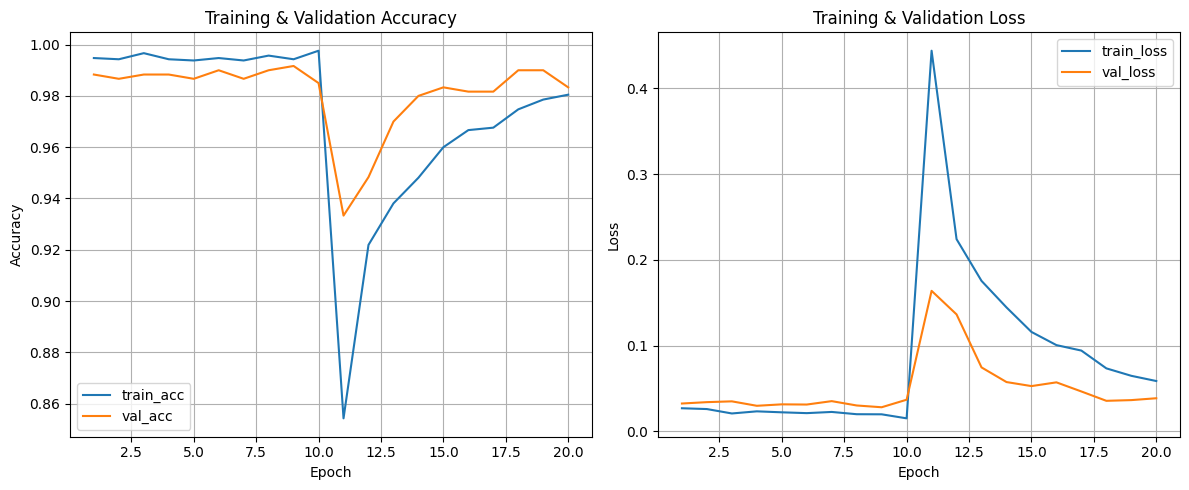

Saved training_acc_loss.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Provide the history objects you used. If you only used one, set the other to None.
# e.g.
# history_head = history  # result from model.fit(...) for head phase
# history_ft = history2   # result from model.fit(...) for fine tune phase
h_head = globals().get('history_head', None)
h_ft   = globals().get('history_ft', None)

def get_history_dict(h):
    if h is None:
        return None
    # some Keras returns History object, some return a dict
    hist = h.history if hasattr(h, 'history') else h
    return hist

hh = get_history_dict(h_head)
hf = get_history_dict(h_ft)

# Build combined series
def combine_series(h1, h2, key):
    series = []
    if h1 is not None and key in h1:
        series += list(h1[key])
    if h2 is not None and key in h2:
        series += list(h2[key])
    return np.array(series)

acc = combine_series(hh, hf, 'accuracy')          # training accuracy
val_acc = combine_series(hh, hf, 'val_accuracy')  # validation accuracy
loss = combine_series(hh, hf, 'loss')
val_loss = combine_series(hh, hf, 'val_loss')

# X axis: epoch numbers starting from 1
epochs = np.arange(1, 1 + max(len(acc), len(loss)))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
if len(acc)>0:
    plt.plot(epochs[:len(acc)], acc, label='train_acc')
if len(val_acc)>0:
    plt.plot(epochs[:len(val_acc)], val_acc, label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training & Validation Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
if len(loss)>0:
    plt.plot(epochs[:len(loss)], loss, label='train_loss')
if len(val_loss)>0:
    plt.plot(epochs[:len(val_loss)], val_loss, label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training & Validation Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig('training_acc_loss.png', dpi=150)
plt.show()

print("Saved training_acc_loss.png")


In [45]:
# 10. Save Keras model and convert to TFLite (float and quantized)
MODEL_PATH = '/content/otitis_mobilenet_v2.h5'
model.save(MODEL_PATH)
print("Saved Keras model to:", MODEL_PATH)

# Convert to TFLite (float)
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open('/content/otitis_model.tflite', 'wb').write(tflite_model)
print("Saved TFLite model (float): /content/otitis_model.tflite")

# Quantize (dynamic range) for smaller size
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant = converter.convert()
open('/content/otitis_model_quant.tflite', 'wb').write(tflite_quant)
print("Saved quantized TFLite model: /content/otitis_model_quant.tflite")


Saved Keras model to: /content/otitis_mobilenet_v2.h5
Saved artifact at '/tmp/tmp6rlyu3i9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_655')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133585499669520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133585553794128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133588255321808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133585553800464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133585499668560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133585553795280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133583058192144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133583058197904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133583249575952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133585499677008: TensorSpe

In [46]:
import tensorflow as tf

MODEL_PATH = "/content/otitis_mobilenet_v2.h5"   # adjust if needed

keras_model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully:", keras_model.name)
keras_model.summary()


Model loaded successfully: functional_5


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,207 (9.87 MB)

 Trainable params: 2,190,661 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 2 (12.00 B)

✅ Model loaded
✅ Grad-CAM model ready (single-graph)

===== PREDICTION RESULT =====
Predicted Class: Acute Otitis Media
Confidence: 100.00%

Full Softmax Probabilities:
- Acute Otitis Media: 100.00%
- Cerumen Impaction: 0.00%
- Chronic Otitis Media: 0.00%
- Myringosclerosis: 0.00%
- Normal: 0.00%


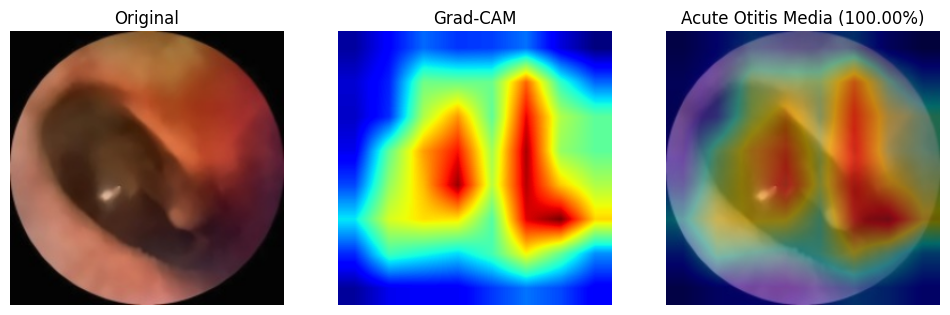

In [52]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
MODEL_PATH = "/content/otitis_mobilenet_v2.h5"
IMG_PATH = "/content/otitis_dataset_preprocessed_retry/train/Acute Otitis Media/aom (101)_61713498.jpg"
IMG_SIZE = (256,256)

CLASS_NAMES = [
    "Acute Otitis Media",
    "Cerumen Impaction",
    "Chronic Otitis Media",
    "Myringosclerosis",
    "Normal"
]

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded")

# =========================
# BUILD GRAD-CAM MODEL
# =========================
base = model.get_layer("mobilenetv2_1.00_224")
last_conv = base.get_layer("out_relu")

head_input = tf.keras.Input(shape=base.output.shape[1:])
x = head_input
for layer in model.layers[2:]:   # dense, dropout, dense
    x = layer(x)
head_model = tf.keras.Model(head_input, x)

grad_model = tf.keras.Model(
    inputs=base.input,
    outputs=[last_conv.output, head_model(base.output)]
)

print("✅ Grad-CAM model ready (single-graph)")

# =========================
# PREPROCESS
# =========================
def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Image not found: {path}")

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(2.0,(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    return img, img[None,...]

orig_norm, inp = preprocess_image(IMG_PATH)
inp = tf.convert_to_tensor(inp)

# =========================
# PREDICTION + GRAD-CAM
# =========================
with tf.GradientTape() as tape:
    conv_out, preds = grad_model(inp, training=False)
    pred_idx = tf.argmax(preds[0])
    loss = preds[:, pred_idx]

grads = tape.gradient(loss, conv_out)

weights = tf.reduce_mean(grads, axis=(0,1,2))
cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)

cam = tf.maximum(cam, 0)
cam /= tf.reduce_max(cam) + 1e-8
cam = cam.numpy()

probs = preds[0].numpy()
idx = int(np.argmax(probs))
conf = probs[idx]
label = CLASS_NAMES[idx]

print("\n===== PREDICTION RESULT =====")
print("Predicted Class:", label)
print(f"Confidence: {conf*100:.2f}%\n")

print("Full Softmax Probabilities:")
for c,p in zip(CLASS_NAMES, probs):
    print(f"- {c}: {p*100:.2f}%")

# =========================
# VISUALIZATION
# =========================
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, (IMG_SIZE[1], IMG_SIZE[0]))
orig = orig.astype(np.uint8)

cam_resized = cv2.resize(cam, (orig.shape[1], orig.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{label} ({conf*100:.2f}%)")
plt.axis("off")

plt.show()


In [53]:
MODEL_PATH = "otitis_mobilenet_v2.h5"       # your trained model
IMG_PATH = "//content/otitis_dataset_preprocessed_retry/train/Acute Otitis Media/aom (101)_61713498.jpg"                # external image path
IMG_SIZE = (256, 256)                       # same size used during training

# Class names (same order as train_gen.class_indices)
CLASS_NAMES = [
    "Acute Otitis Media",
    "Cerumen Impaction",
    "Chronic Otitis Media",
    "Myringosclerosis",
    "Normal"
]

# -------------------------------
# Load model
# -------------------------------
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded!")

# -------------------------------
# Preprocessing function (same as training)
# -------------------------------
def preprocess_image(img_path, img_size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found:", img_path)

    # Convert to LAB for CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    lab = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # Denoise
    denoised = cv2.fastNlMeansDenoisingColored(img_clahe, None, 10, 10, 7, 21)

    # Resize
    resized = cv2.resize(denoised, img_size)

    # Normalize → (0–1)
    img_norm = resized.astype("float32") / 255.0

    # Add batch dimension → (1, 224, 224, 3)
    return np.expand_dims(img_norm, axis=0)

# -------------------------------
# Prediction
# -------------------------------
img_tensor = preprocess_image(IMG_PATH)
pred = model.predict(img_tensor)[0]

# Get predicted index
idx = np.argmax(pred)
confidence = pred[idx]

print("\n===== PREDICTION RESULT =====")
print("Predicted Class:", CLASS_NAMES[idx])
print("Confidence:", round(float(confidence)*100, 2), "%\n")

print("Full Softmax Probabilities:")
for cls, p in zip(CLASS_NAMES, pred):
    print(f"- {cls}: {round(float(p)*100, 2)}%")

Model loaded!
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

===== PREDICTION RESULT =====
Predicted Class: Acute Otitis Media
Confidence: 100.0 %

Full Softmax Probabilities:
- Acute Otitis Media: 100.0%
- Cerumen Impaction: 0.0%
- Chronic Otitis Media: 0.0%
- Myringosclerosis: 0.0%
- Normal: 0.0%


✅ Model loaded
✅ Grad-CAM model ready (stable)

===== PREDICTION RESULT =====
Predicted Class: Myringosclerosis
Confidence: 99.81%

Full Softmax Probabilities:
- Acute Otitis Media: 0.01%
- Cerumen Impaction: 0.00%
- Chronic Otitis Media: 0.00%
- Myringosclerosis: 99.81%
- Normal: 0.18%


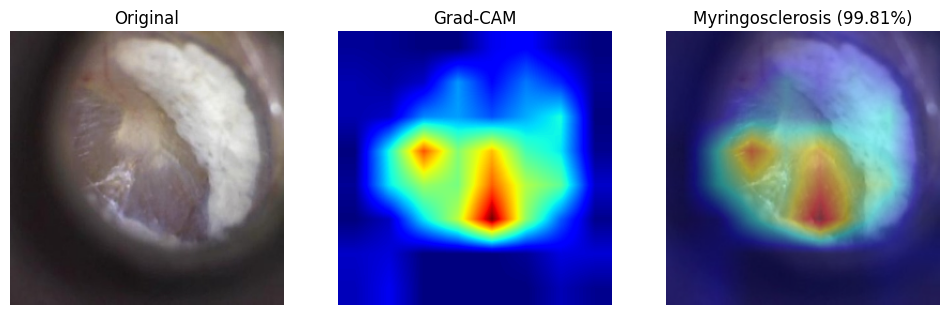

In [55]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
MODEL_PATH = "/content/otitis_mobilenet_v2.h5"
IMG_PATH = "/content/otitis_dataset/test/Myringosclerosis/mys (397).jpg"
IMG_SIZE = (256,256)

CLASS_NAMES = [
    "Acute Otitis Media",
    "Cerumen Impaction",
    "Chronic Otitis Media",
    "Myringosclerosis",
    "Normal"
]

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded")

# =========================
# EXTRACT BASE + HEAD (SAFE)
# =========================
base = model.get_layer("mobilenetv2_1.00_224")
last_conv = base.get_layer("out_relu")

# rebuild classifier head explicitly
x = tf.keras.Input(shape=base.output.shape[1:])
y = x
for layer in model.layers[2:]:   # dense, dropout, dense
    y = layer(y)
head = tf.keras.Model(x, y)

# =========================
# FINAL GRAD-CAM MODEL (SINGLE GRAPH)
# =========================
grad_model = tf.keras.Model(
    inputs=base.input,
    outputs=[last_conv.output, head(base.output)]
)

print("✅ Grad-CAM model ready (stable)")

# =========================
# PREPROCESS IMAGE
# =========================
def preprocess(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    l = cv2.createCLAHE(2.0,(8,8)).apply(l)
    img = cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR)

    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    return img, img[None,...]

orig_norm, inp = preprocess(IMG_PATH)
inp = tf.convert_to_tensor(inp)

# =========================
# PREDICTION + GRAD-CAM
# =========================
with tf.GradientTape() as tape:
    conv_out, preds = grad_model(inp, training=False)
    pred_idx = tf.argmax(preds[0])
    loss = preds[:, pred_idx]

grads = tape.gradient(loss, conv_out)

# channel importance
weights = tf.reduce_mean(grads, axis=(0,1,2))
cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)

cam = tf.maximum(cam, 0)
cam /= tf.reduce_max(cam) + 1e-8
cam = cam.numpy()

# =========================
# PRINT PREDICTION
# =========================
probs = preds[0].numpy()
idx = int(np.argmax(probs))
conf = probs[idx]
label = CLASS_NAMES[idx]

print("\n===== PREDICTION RESULT =====")
print("Predicted Class:", label)
print(f"Confidence: {conf*100:.2f}%\n")

print("Full Softmax Probabilities:")
for c,p in zip(CLASS_NAMES, probs):
    print(f"- {c}: {p*100:.2f}%")

# =========================
# OVERLAY
# =========================
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, IMG_SIZE)

cam_resized = cv2.resize(cam, (orig.shape[1], orig.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heatmap, 0.4, 0)

# =========================
# DISPLAY
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{label} ({conf*100:.2f}%)")
plt.axis("off")

plt.show()
